**Name** : Shivraj Ramesh Nalawade

**PRN**  : 202301060008

Github Repo: https://github.com/shivraj-nalawade/Explainable-AI-Techniques-in-Machine-Learning-.git

# Explainable AI (XAI) on Titanic Dataset

## Step 1: Dataset Understanding and Exploratory Data Analysis (EDA)

We first explore the dataset to understand structure, missing values, and relationships.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Insight:
Dataset contains missing values in Age and Embarked, which will be handled in preprocessing.

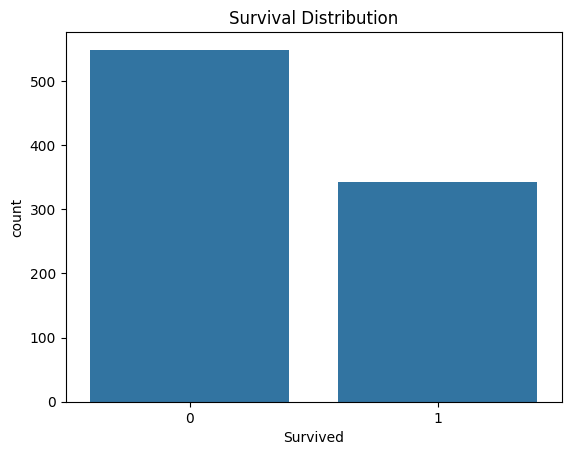

In [6]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

### Analysis:
The dataset is slightly imbalanced, with more passengers not surviving.

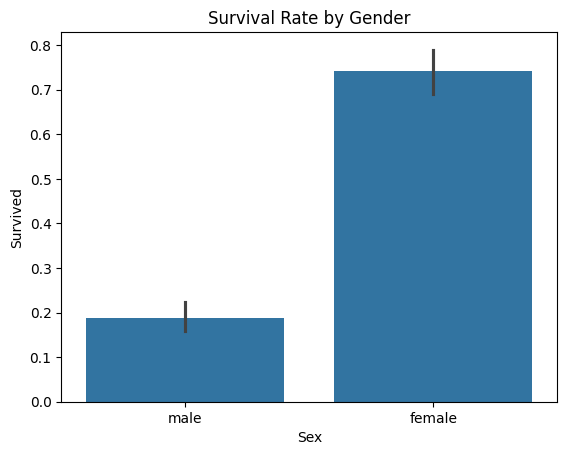

In [7]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

### Analysis:
Female passengers have a significantly higher survival rate, indicating gender is a strong predictor.

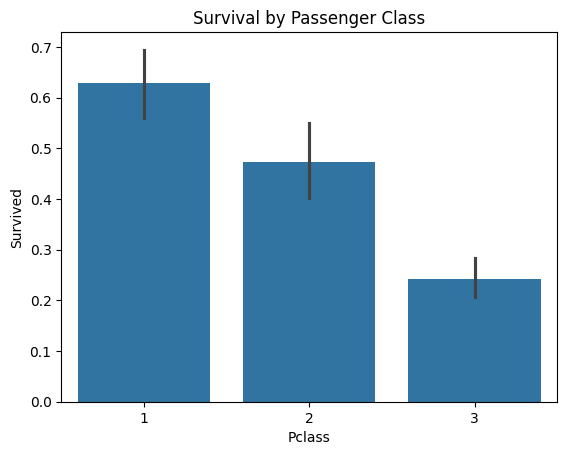

In [8]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

### Analysis:
Passengers in higher classes had better survival chances, reflecting socio-economic influence.

## Step 2: Data Preprocessing

Cleaning data, handling missing values, and encoding categorical variables.

In [9]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(['Cabin','Name','Ticket','PassengerId'], axis=1, inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_890/4081982215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_890/4081982215.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

### Explanation:
- Median used for Age to reduce outlier impact
- Mode used for Embarked
- One-hot encoding converts categorical variables to numeric

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 3: Model Training and Evaluation

Using Random Forest Classifier for prediction.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



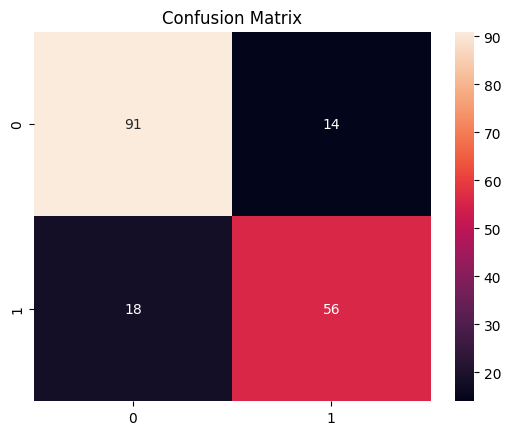

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Analysis:
The model performs well but some misclassifications exist due to overlapping patterns.

## Step 4: Explainable AI Techniques

Applying SHAP and LIME to understand model behavior.

In [15]:
# Ensure numeric data by converting all columns to float, which handles booleans as well.
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [24]:
import shap

# Using TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model)
# explainer.shap_values for binary classification often returns a 3D array
# of shape (n_samples, n_features, n_classes) for sklearn tree models.
shap_values_all_classes = explainer.shap_values(X_train)

# explainer.expected_value will be a list or array [expected_value_class0, expected_value_class1]

shap_values_for_positive_class = shap_values_all_classes[:, :, 1]
expected_value_for_positive_class = explainer.expected_value[1]


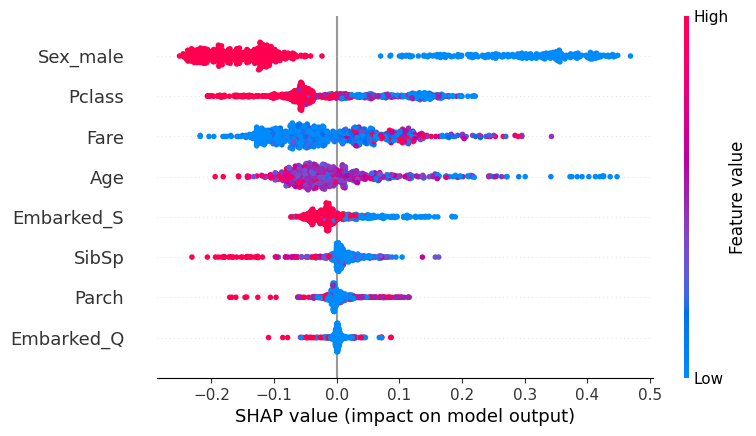

In [25]:
import shap

# Now, shap_values_for_positive_class is a numpy array (N, M)
# and expected_value_for_positive_class is a scalar.

robust_explanation = shap.Explanation(
    values=shap_values_for_positive_class,
    base_values=expected_value_for_positive_class,
    data=X_train.values,  # Pass the underlying numpy array of X_train
    feature_names=X_train.columns.tolist() # Pass the list of column names
)

shap.plots.beeswarm(robust_explanation)

### Analysis:
SHAP shows that Sex, Fare, and Pclass are the most influential features affecting predictions.

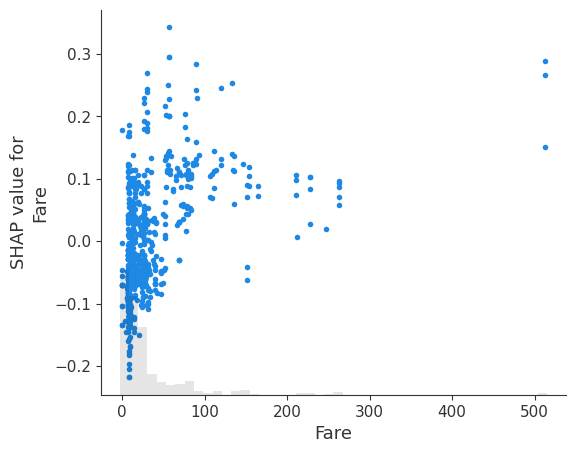

In [27]:
shap.plots.scatter(robust_explanation[:, 'Fare'])

### Analysis:
Higher fare values increase survival probability, indicating wealth advantage.

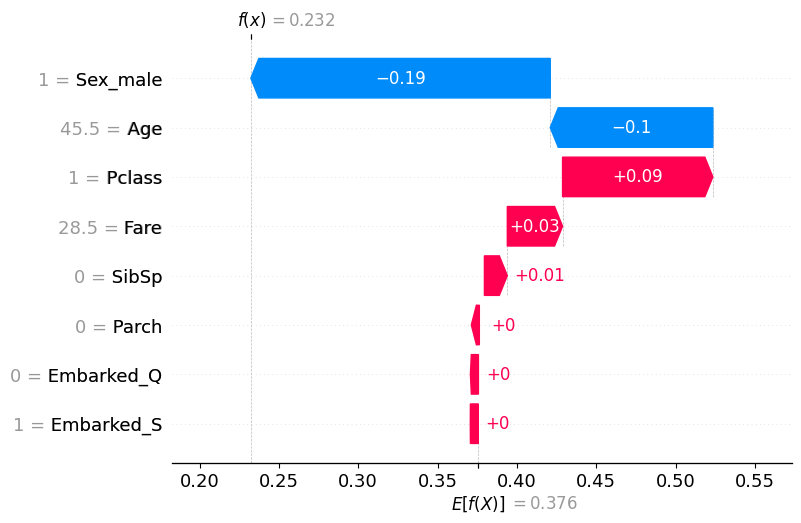

In [29]:
shap.plots.waterfall(robust_explanation[0])

### Analysis:
Waterfall plot explains individual prediction contributions.

In [32]:
!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import pandas as pd

# Wrapper function to ensure predict_proba receives a DataFrame with column names
def predict_proba_wrapper(data):
    df_data = pd.DataFrame(data, columns=X_train.columns)
    return model.predict_proba(df_data)

lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=['Not Survived','Survived'],
    mode='classification'
)

exp = lime.explain_instance(X_test.values[0], predict_proba_wrapper)
exp.show_in_notebook()

### Analysis:
LIME explains individual predictions by approximating model locally.

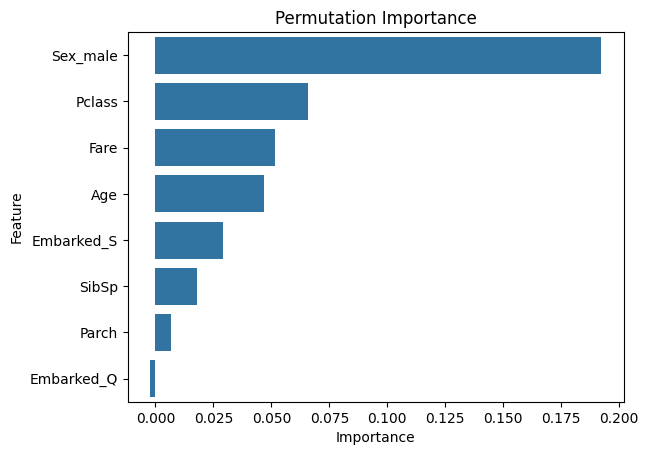

In [33]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=perm_df)
plt.title("Permutation Importance")
plt.show()

### Analysis:
Permutation importance confirms key features like Sex, Fare, and Pclass.

## Step 5: Visualization and Final Analysis

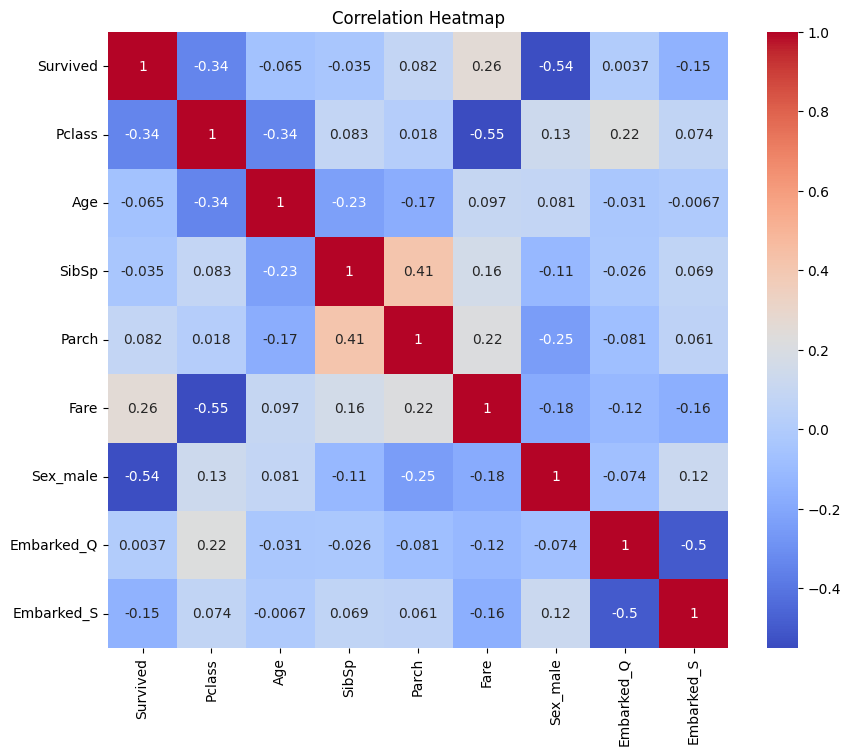

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Analysis:
No strong multicollinearity detected, ensuring model stability.

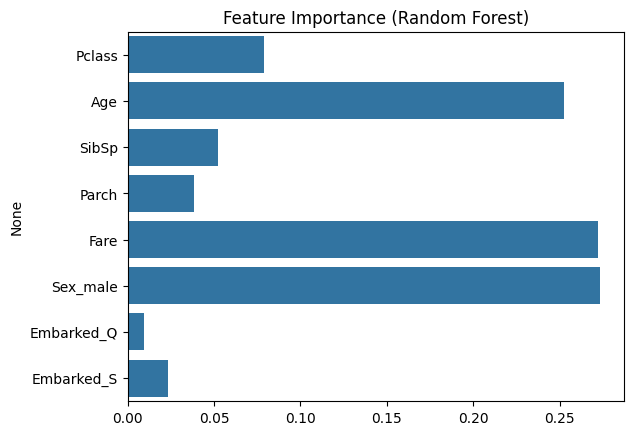

In [36]:
importances = model.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance (Random Forest)")
plt.show()

### Analysis:
The feature importance plot shows that the model relies heavily on 'Sex', 'Fare', and 'Pclass'. These features dominate the model’s decision-making process.

## Bias and Fairness Analysis

Model shows bias toward female and higher-class passengers, reflecting dataset patterns but raising fairness concerns.

## Conclusion

Explainable AI techniques like SHAP and LIME provide transparency, improve trust, and help identify important features and biases in the model.